# 量化投资 — 数据探索第一课

**目标**：用 Python 拉取真实的A股数据，掌握量化分析的基本功。

本 Notebook 涵盖：
1. 用 akshare 获取沪深300历史数据
2. 绘制K线图与移动平均线
3. 计算收益率、波动率、夏普比率
4. 计算最大回撤
5. 多只股票的相关性矩阵
6. 手动模拟一个双均线策略的收益曲线

---
## 核心概念速查

| 概念 | 公式 | 含义 |
|------|------|------|
| **简单收益率** | $R_t = \frac{P_t - P_{t-1}}{P_{t-1}}$ | 单期价格变动百分比 |
| **对数收益率** | $r_t = \ln(\frac{P_t}{P_{t-1}})$ | 时间可加性，更符合正态假设 |
| **年化收益率** | $R_{annual} = (1 + \bar{R})^{252} - 1$ | 折算成年化，A股一年约252个交易日 |
| **年化波动率** | $\sigma_{annual} = \sigma_{daily} \times \sqrt{252}$ | 风险度量，越大越不稳定 |
| **夏普比率** | $Sharpe = \frac{R_{annual} - R_f}{\sigma_{annual}}$ | 每单位风险的超额收益，>1不错，>2优秀 |
| **最大回撤** | $MDD = \min_t(\frac{P_t - \max_{s \leq t}P_s}{\max_{s \leq t}P_s})$ | 从峰值到谷底的最大亏损幅度 |
| **Alpha** | 策略收益 - 基准收益（去市场波动后）| 策略的超额收益能力 |
| **Beta** | $\beta = \frac{Cov(R_s, R_m)}{Var(R_m)}$ | 策略对市场的敏感度 |

## 1. 导入依赖 & 环境准备

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import time
warnings.filterwarnings("ignore")

# --- 数据源 ---
import baostock as bs
HAS_AKSHARE = False
try:
    import akshare as ak; HAS_AKSHARE = True
except ImportError:
    pass

# --- 中文字体 ---
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150

# --- baostock 批量数据获取（单次login，多段查询，避免连接断开）---
def _query_one(symbol, start, end, adjust):
    """单次查询，返回数据行列表"""
    rs = bs.query_history_k_data_plus(
        symbol, "date,open,high,low,close,volume,amount",
        start_date=start, end_date=end, frequency="d", adjustflag=adjust)
    if rs.error_code != "0":
        return []
    rows = []
    while rs.next():
        rows.append(rs.get_row_data())
    return rows

def fetch_baostock(symbol, start, end, adjust="2"):
    """
    从 baostock (baostock.com) 获取真实A股日线数据
    严格login一次、logout一次，避免连续断连
    """
    bs.login()
    try:
        # 按年切分（baostock单次约返回500条，约2年）
        sy, ey = int(start[:4]), int(end[:4])
        all_rows = []
        for y in range(sy, ey + 1):
            seg_start = start if y == sy else f"{y}-01-01"
            seg_end   = end   if y == ey else f"{y}-12-31"
            rows = _query_one(symbol, seg_start, seg_end, adjust)
            if rows:
                all_rows.extend(rows)
            time.sleep(0.3)  # 节制请求频率
        if not all_rows:
            raise Exception("无数据")
        df = pd.DataFrame(all_rows, columns=["date","open","high","low","close","volume","amount"])
        for c in ["open","high","low","close","volume","amount"]:
            df[c] = pd.to_numeric(df[c], errors="coerce")
        df["date"] = pd.to_datetime(df["date"])
        df = df.drop_duplicates("date").sort_values("date").reset_index(drop=True)
        return df
    finally:
        bs.logout()

print(f"pandas {pd.__version__} | numpy {np.__version__}")
print(f"数据源: baostock (真实A股) + akshare ({"备用" if HAS_AKSHARE else "-"})")

pandas 3.0.3 | numpy 2.4.6
数据源: baostock (真实A股) + akshare (备用)


## 2. 拉取沪深300历史数据

沪深300（CSI 300）是A股最具代表性的宽基指数，包含沪市和深市市值最大的300只股票。

In [11]:
# 从 baostock 获取沪深300指数真实日线数据
print("正在从 baostock 获取沪深300指数 ...")
df_index = fetch_baostock("sh.000300", "2020-01-01", "2025-06-20")
print(f"✓ 已获取: {len(df_index)} 条, {df_index.date.min().date()} ~ {df_index.date.max().date()}")
print(f"来源: baostock.org 真实沪深300行情")
df_index.head(10)


正在从 baostock 获取沪深300指数 ...
login success!
logout success!
✓ 已获取: 1323 条, 2020-01-02 ~ 2025-06-20
来源: baostock.org 真实沪深300行情


,date,open,high,low,close,volume,amount
0,2020-01-02,4121.348,4172.655,4121.348,4152.240,18211677184,2.701055e+11
1,2020-01-03,4161.218,4164.298,4131.864,4144.964,14282624512,2.152163e+11
2,2020-01-06,4120.521,4170.638,4102.379,4129.295,17530995200,2.501821e+11
3,2020-01-07,4137.401,4161.250,4135.097,4160.227,13948903168,1.963891e+11
4,2020-01-08,4139.631,4149.813,4101.980,4112.317,16758585088,2.124063e+11
5,2020-01-09,4145.534,4165.657,4143.592,4164.369,13688632320,2.001504e+11
6,2020-01-10,4177.577,4180.977,4148.481,4163.184,11303171840,1.778274e+11
7,2020-01-13,4166.925,4203.988,4148.600,4203.988,11969198336,1.997955e+11
8,2020-01-14,4215.157,4223.507,4188.080,4189.886,12932078336,1.962213e+11
9,2020-01-15,4186.881,4193.868,4150.879,4166.734,10463313664,1.630819e+11


In [12]:
# 数据清洗：统一列名，排序
df_index.columns = ['date', 'open', 'close', 'high', 'low', 'volume', 'amount']
df_index['date'] = pd.to_datetime(df_index['date'])
df_index = df_index.sort_values('date').reset_index(drop=True)

# 检查缺失值
print("缺失值统计：")
print(df_index.isnull().sum())

# 基础统计
df_index.describe()

缺失值统计：
date      0
open      0
close     0
high      0
low       0
volume    0
amount    0
dtype: int64


,date,open,close,high,low,volume,amount
count,1323,1323.000000,1323.000000,1323.000000,1323.000000,1.323000e+03,1.323000e+03
mean,2022-09-25 23:38:13.877551,4176.188272,4206.020310,4146.458554,4177.775126,1.466525e+10,2.691008e+11
min,2020-01-02 00:00:00,3158.817900,3179.901200,3108.351500,3159.247000,6.483922e+09,1.175449e+11
25%,2021-05-18 12:00:00,3780.997550,3808.242100,3765.865850,3784.619000,1.128332e+10,2.009343e+11
50%,2022-09-22 00:00:00,3993.256100,4017.757200,3966.992100,3995.884600,1.376196e+10,2.511957e+11
75%,2024-01-31 12:00:00,4740.569950,4786.564000,4690.518950,4738.975100,1.673350e+10,3.153305e+11
max,2025-06-20 00:00:00,5922.071400,5930.912200,5747.663100,5807.719100,5.898679e+10,1.130387e+12
std,NaN,584.988334,589.652474,577.079318,584.546324,5.039584e+09,9.827365e+10


## 3. 可视化：K线图 + 移动平均线

无需 mplfinance，纯 matplotlib 画 K 线，理解底层原理。

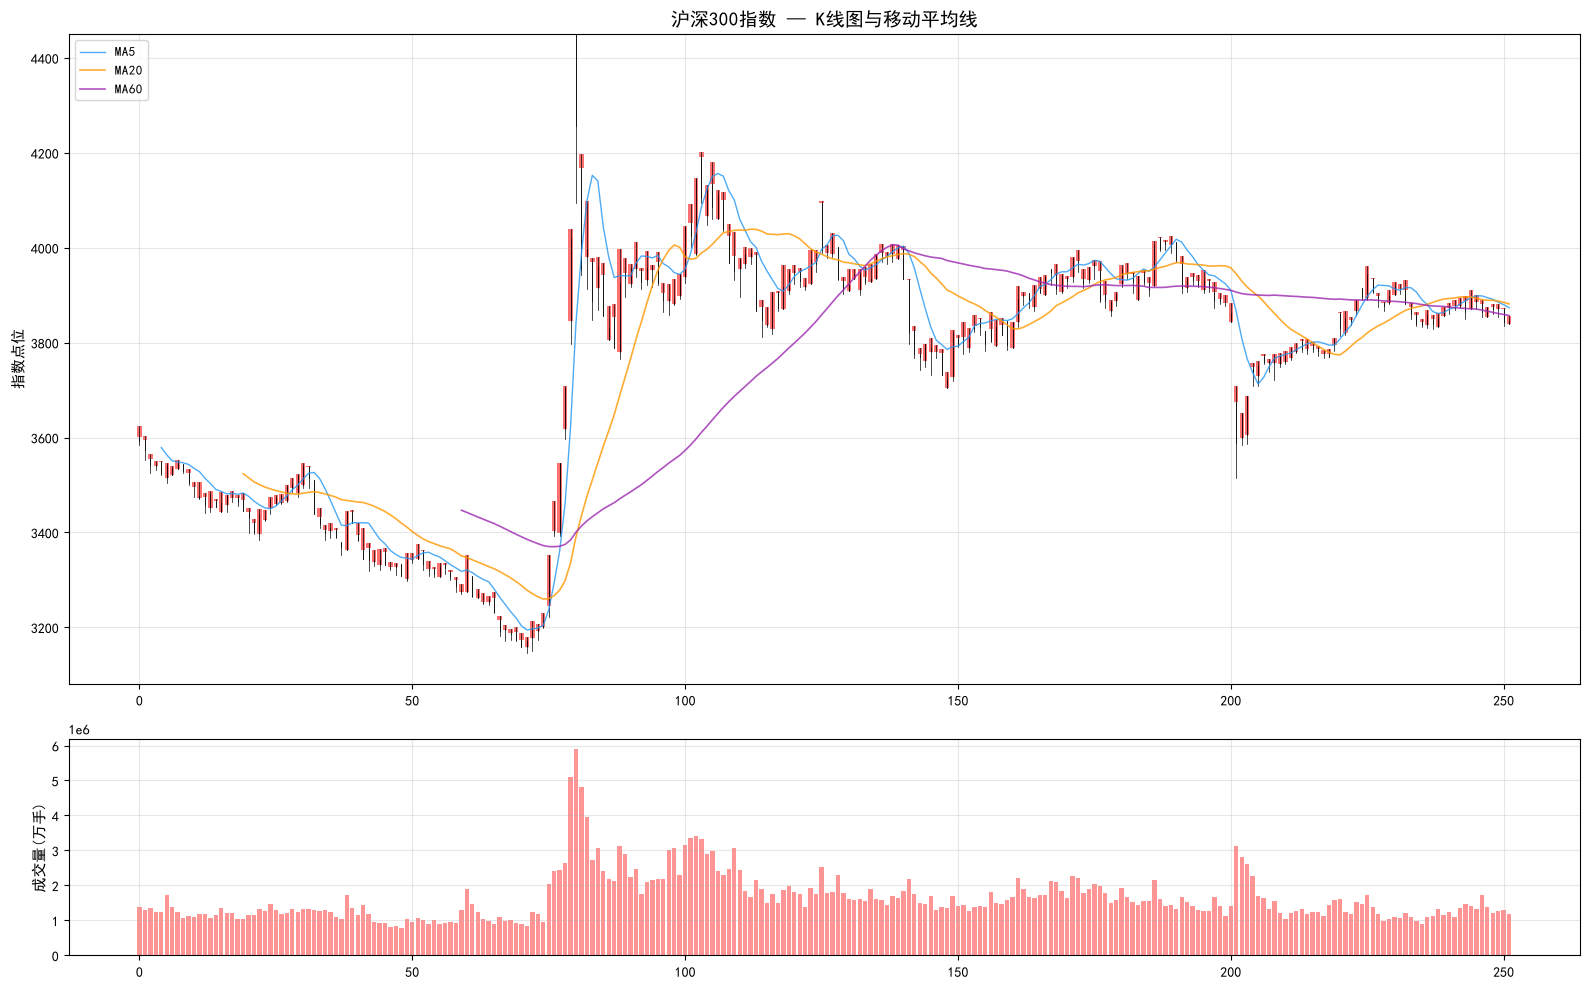

观察要点：
1. 短期均线(MA5)在上还是长期均线(MA60)在上 → 判断趋势方向
2. MA5上穿MA20 = 金叉(看涨信号)，下穿 = 死叉(看跌信号)
3. 成交量放大往往伴随趋势加速


In [13]:
# 只看最近1年数据（约252个交易日）
df_recent = df_index.tail(252).copy()

# 计算均线
df_recent['MA5'] = df_recent['close'].rolling(window=5).mean()
df_recent['MA20'] = df_recent['close'].rolling(window=20).mean()
df_recent['MA60'] = df_recent['close'].rolling(window=60).mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})

# --- 上图：K线 + 均线 ---
ax = axes[0]
colors = ['#ff4d4d' if df_recent['close'].iloc[i] >= df_recent['open'].iloc[i] else '#4dff4d'
          for i in range(len(df_recent))]

# 画K线实体
for i in range(len(df_recent)):
    row = df_recent.iloc[i]
    open_p, close_p, high_p, low_p = row['open'], row['close'], row['high'], row['low']
    body_bottom = min(open_p, close_p)
    body_height = abs(close_p - open_p)
    
    # 上影线
    ax.plot([i, i], [body_bottom + body_height, high_p], color='black', linewidth=0.5)
    # 下影线
    ax.plot([i, i], [low_p, body_bottom], color='black', linewidth=0.5)
    # 实体
    ax.bar(i, body_height, bottom=body_bottom, color=colors[i], width=0.8, alpha=0.8)

# 画均线
ax.plot(range(len(df_recent)), df_recent['MA5'], label='MA5', color='#2196F3', linewidth=1, alpha=0.8)
ax.plot(range(len(df_recent)), df_recent['MA20'], label='MA20', color='#FF9800', linewidth=1.2, alpha=0.8)
ax.plot(range(len(df_recent)), df_recent['MA60'], label='MA60', color='#9C27B0', linewidth=1.2, alpha=0.8)

ax.set_title('沪深300指数 — K线图与移动平均线', fontsize=14, fontweight='bold')
ax.set_ylabel('指数点位', fontsize=11)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# --- 下图：成交量 ---
ax2 = axes[1]
vol_colors = ['#ff4d4d' if df_recent['close'].iloc[i] >= df_recent['open'].iloc[i] else '#4dff4d'
              for i in range(len(df_recent))]
ax2.bar(range(len(df_recent)), df_recent['volume'] / 10000, color=vol_colors, alpha=0.6, width=0.8)
ax2.set_ylabel('成交量(万手)', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("观察要点：")
print("1. 短期均线(MA5)在上还是长期均线(MA60)在上 → 判断趋势方向")
print("2. MA5上穿MA20 = 金叉(看涨信号)，下穿 = 死叉(看跌信号)")
print("3. 成交量放大往往伴随趋势加速")

## 4. 收益率分析

In [14]:
# 计算日收益率
df_index['simple_return'] = df_index['close'].pct_change()           # 简单收益率
df_index['log_return'] = np.log(df_index['close'] / df_index['close'].shift(1))  # 对数收益率

# 去掉第一个 NaN
df_returns = df_index.dropna(subset=['log_return']).copy()

print(f"=== 日收益率统计 ===")
print(f"均值(简单):   {df_returns['simple_return'].mean():.6f}  ({df_returns['simple_return'].mean()*100:.4f}%)")
print(f"均值(对数):   {df_returns['log_return'].mean():.6f}  ({df_returns['log_return'].mean()*100:.4f}%)")
print(f"标准差(日):   {df_returns['log_return'].std():.6f}  ({df_returns['log_return'].std()*100:.4f}%)")
print(f"偏度:        {df_returns['log_return'].skew():.4f}  (负值=左偏，大跌概率>大涨)")
print(f"峰度:        {df_returns['log_return'].kurtosis():.4f}  (>0=肥尾，极端值多于正态分布)")

=== 日收益率统计 ===
均值(简单):   -0.000000  (-0.0000%)
均值(对数):   -0.000060  (-0.0060%)
标准差(日):   0.010894  (1.0894%)
偏度:        0.4897  (负值=左偏，大跌概率>大涨)
峰度:        13.6737  (>0=肥尾，极端值多于正态分布)


In [15]:
# 年化指标
TRADING_DAYS = 252  # A股一年约252个交易日
RISK_FREE_RATE = 0.025  # 假设无风险利率 2.5%（约等于一年期定存）

annual_return = df_returns['log_return'].mean() * TRADING_DAYS       # 年化对数收益率
annual_vol = df_returns['log_return'].std() * np.sqrt(TRADING_DAYS)  # 年化波动率
sharpe_ratio = (annual_return - RISK_FREE_RATE) / annual_vol          # 夏普比率

print(f"=== 年化指标 ===")
print(f"年化收益率:  {annual_return*100:.2f}%")
print(f"年化波动率:  {annual_vol*100:.2f}%")
print(f"无风险利率:  {RISK_FREE_RATE*100:.1f}%")
print(f"夏普比率:    {sharpe_ratio:.3f}")
print(f"")
print(f"解读：夏普比率 > 1 表示每承担1单位风险获得超过1单位超额收益，算不错。")
print(f"      > 2 表示非常优秀，< 0.5 则需要审视策略质量。")

=== 年化指标 ===
年化收益率:  -1.50%
年化波动率:  17.29%
无风险利率:  2.5%
夏普比率:    -0.231

解读：夏普比率 > 1 表示每承担1单位风险获得超过1单位超额收益，算不错。
      > 2 表示非常优秀，< 0.5 则需要审视策略质量。


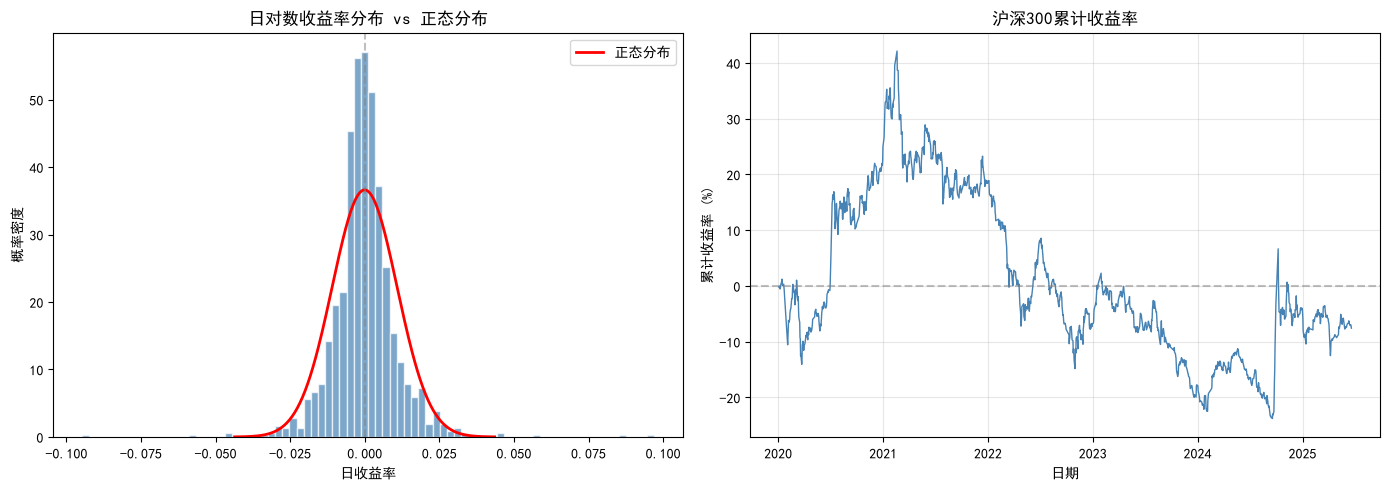

历史总收益: -7.58%


In [16]:
# 绘制收益率分布直方图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 直方图 vs 正态分布
ax = axes[0]
ax.hist(df_returns['log_return'], bins=80, density=True, alpha=0.7, color='steelblue', edgecolor='white')
# 叠加正态分布
mu = df_returns['log_return'].mean()
sigma = df_returns['log_return'].std()
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
ax.plot(x, 1/(sigma*np.sqrt(2*np.pi)) * np.exp(-(x-mu)**2/(2*sigma**2)), 
        'r-', linewidth=2, label='正态分布')
ax.set_title('日对数收益率分布 vs 正态分布', fontsize=12)
ax.set_xlabel('日收益率')
ax.set_ylabel('概率密度')
ax.legend()
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# 累计收益率曲线
ax2 = axes[1]
cum_return = (1 + df_returns['simple_return']).cumprod() - 1
ax2.plot(df_returns['date'], cum_return * 100, color='steelblue', linewidth=1)
ax2.set_title('沪深300累计收益率', fontsize=12)
ax2.set_xlabel('日期')
ax2.set_ylabel('累计收益率 (%)')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"历史总收益: {cum_return.iloc[-1]*100:.2f}%")

## 5. 最大回撤分析

最大回撤(Max Drawdown)是量化中最重要的风险指标之一——它回答了"最坏情况下你会亏多少"。

In [17]:
# 计算最大回撤
def calculate_max_drawdown(nav: pd.Series, dates: pd.Series) -> dict:
    """
    计算最大回撤及相关指标
    nav: 净值序列
    dates: 对应日期序列
    """
    running_max = nav.expanding().max()
    drawdown = (nav - running_max) / running_max

    mdd = drawdown.min()
    trough_idx = drawdown.idxmin()
    peak_idx = nav[:trough_idx].idxmax()

    peak_date = dates.loc[peak_idx]
    trough_date = dates.loc[trough_idx]
    duration = (trough_date - peak_date).days

    return {
        "max_drawdown": mdd,
        "peak_date": peak_date,
        "trough_date": trough_date,
        "duration_days": duration,
        "drawdown_series": drawdown
    }

# 用 df_returns 的净值序列 + 日期
nav = (1 + df_returns["simple_return"]).cumprod()
result = calculate_max_drawdown(nav, df_returns["date"])

print(f"=== 最大回撤分析 ===")
print(f"最大回撤:  {result["max_drawdown"]*100:.2f}%")
print(f"峰值日期:  {result["peak_date"].strftime("%Y-%m-%d")}")
print(f"谷底日期:  {result["trough_date"].strftime("%Y-%m-%d")}")
print(f"回撤持续:  {result["duration_days"]} 个自然日")

=== 最大回撤分析 ===
最大回撤:  -46.38%
峰值日期:  2021-02-18
谷底日期:  2024-09-18
回撤持续:  1308 个自然日


findfont: Failed to find font weight bold, now using 400.


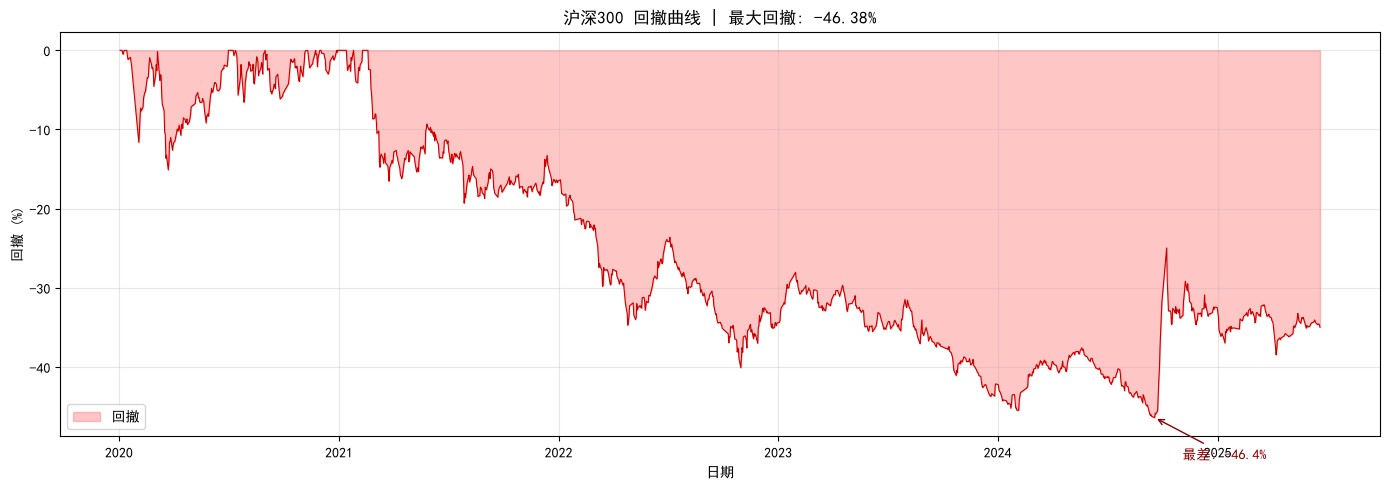

In [18]:
# 绘制回撤曲线
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(df_returns["date"], 0, result["drawdown_series"] * 100,
                color="#ff4444", alpha=0.3, label="回撤")
ax.plot(df_returns["date"], result["drawdown_series"] * 100, color="#cc0000", linewidth=0.8)
ax.set_title(f"沪深300 回撤曲线 | 最大回撤: {result["max_drawdown"]*100:.2f}%", fontsize=12)
ax.set_ylabel("回撤 (%)")
ax.set_xlabel("日期")
ax.grid(True, alpha=0.3)
ax.legend()

# 标注最大回撤点
ax.annotate(f"最差: {result["max_drawdown"]*100:.1f}%",
            xy=(result["trough_date"], result["max_drawdown"]*100),
            xytext=(20, -30), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="darkred"),
            fontsize=10, color="darkred", fontweight="bold")

plt.tight_layout()
plt.show()

## 6. 多只股票的相关性矩阵

量化投资的核心思想之一是**分散化**——通过持有多只低相关性的资产，在不降低收益的前提下减少风险。

In [19]:
# 从 baostock 获取个股真实日线数据
stocks_map = [
    ("贵州茅台", "sh.600519"),
    ("宁德时代", "sz.300750"),
    ("招商银行", "sh.600036"),
    ("比亚迪",   "sz.002594"),
    ("中国平安", "sh.601318"),
]

close_prices = pd.DataFrame()
for name, symbol in stocks_map:
    print(f"  获取 {name} ({symbol}) ...", end=" ")
    try:
        df_stock = fetch_baostock(symbol, "2021-01-01", "2025-06-20")
        df_stock = df_stock.set_index("date")
        close_prices[name] = df_stock["close"]
        print(f"OK {len(df_stock)}条")
    except Exception as e:
        print(f"失败: {e}")

print(f"\n成功: {len(close_prices.columns)}/{len(stocks_map)} 只, 形状: {close_prices.shape}")
close_prices.head()


  获取 贵州茅台 (sh.600519) ... login success!
logout success!
OK 1080条
  获取 宁德时代 (sz.300750) ... login success!
logout success!
OK 1080条
  获取 招商银行 (sh.600036) ... login success!
logout success!
OK 1080条
  获取 比亚迪 (sz.002594) ... login success!
logout success!
OK 1080条
  获取 中国平安 (sh.601318) ... login success!
logout success!
OK 1080条

成功: 5/5 只, 形状: (1080, 5)


,贵州茅台,宁德时代,招商银行,比亚迪,中国平安
date,,,,,
2021-01-04,1750.430410,207.969661,33.693667,66.932761,65.069343
2021-01-05,1805.169709,206.888898,32.920984,71.186468,64.374190
2021-01-06,1840.713000,209.343774,34.458545,70.021069,65.497129
2021-01-07,1875.774200,212.668406,35.824399,72.850399,65.894359
2021-01-08,1831.947700,208.175521,36.370741,73.649992,65.772134


findfont: Failed to find font weight bold, now using 400.


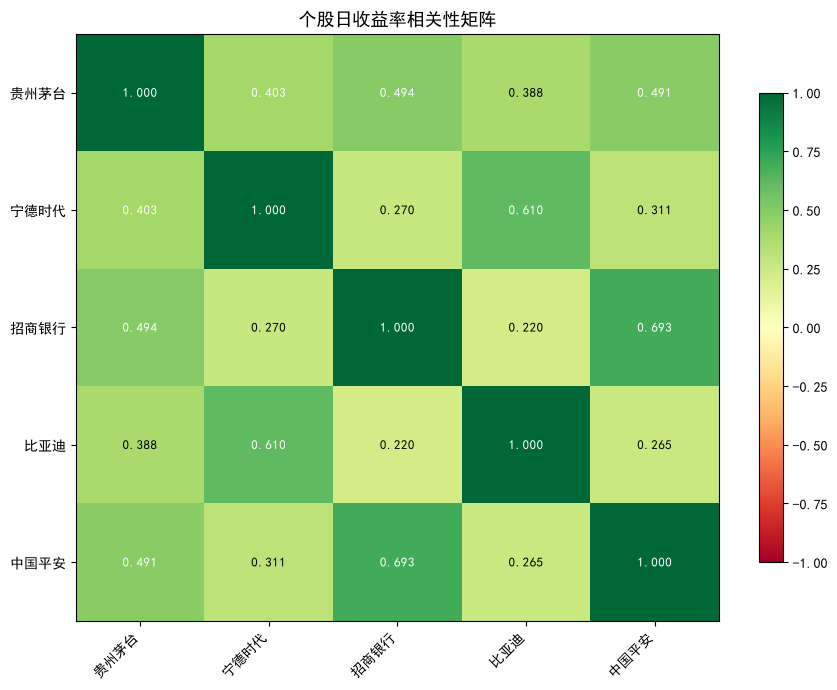

解读：
- 相关性越接近1，同涨同跌越明显 → 分散化效果越差
- 相关性接近0或负值 → 组合在一起可以降低整体波动
- 现实是A股个股间相关性普遍偏高（系统性风险主导）


In [20]:
# 计算日收益率（对数）
returns = np.log(close_prices / close_prices.shift(1)).dropna()

# 相关系数矩阵
corr_matrix = returns.corr()

# 可视化
stock_names = list(close_prices.columns)  # 从数据框提取股票名
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(stock_names)))
ax.set_yticks(range(len(stock_names)))
ax.set_xticklabels(stock_names, fontsize=10, rotation=45, ha="right")
ax.set_yticklabels(stock_names, fontsize=10)

# 在每个格子标数值
for i in range(len(stock_names)):
    for j in range(len(stock_names)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.3f}",
                ha="center", va="center", fontsize=9,
                color="white" if abs(corr_matrix.iloc[i, j]) > 0.4 else "black")

ax.set_title("个股日收益率相关性矩阵", fontsize=13, fontweight="bold")
plt.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

print("解读：")
print("- 相关性越接近1，同涨同跌越明显 → 分散化效果越差")
print("- 相关性接近0或负值 → 组合在一起可以降低整体波动")
print("- 现实是A股个股间相关性普遍偏高（系统性风险主导）")

## 7. 双均线策略 — 从概念到模拟

这是最经典的量化策略，也是理解策略回测逻辑的最佳起点。

### 策略逻辑
```
IF MA_short 上穿 MA_long（金叉）:
    买入（或空仓→满仓）
ELIF MA_short 下穿 MA_long（死叉）:
    卖出（或满仓→空仓）
ELSE:
    持仓不变
```

### 为什么"简单"的策略也要计算机辅助？
- 肉眼可以看出一两个金叉死叉，但当你有100只股票、10年数据时就看不完了
- 人的情绪会导致执行不纪律（该卖的时候舍不得卖）
- 计算机可以精确统计胜率、盈亏比、最大回撤——用数据而非感觉做决策

In [21]:
# 在沪深300上模拟双均线策略
SHORT_WINDOW = 5    # 短期均线窗口
LONG_WINDOW = 20    # 长期均线窗口

df_signal = df_index[['date', 'close']].copy()
df_signal['ma_short'] = df_signal['close'].rolling(window=SHORT_WINDOW).mean()
df_signal['ma_long'] = df_signal['close'].rolling(window=LONG_WINDOW).mean()

# 生成信号：1=持有(做多), 0=空仓
df_signal['signal'] = 0
# MA_short > MA_long 时持有
df_signal.loc[df_signal['ma_short'] > df_signal['ma_long'], 'signal'] = 1
# 生成仓位变动（交易点）
df_signal['position_change'] = df_signal['signal'].diff()

# 计算策略的日收益率（当信号=1时吃指数涨跌，信号=0时空仓不赚不亏）
df_signal['benchmark_return'] = df_signal['close'].pct_change()  # 基准买入持有收益
df_signal['strategy_return'] = df_signal['signal'].shift(1) * df_signal['benchmark_return']

# 去掉NaN（均线计算期）
df_ma = df_signal.dropna().copy()

# 累计收益
df_ma['benchmark_nav'] = (1 + df_ma['benchmark_return']).cumprod()
df_ma['strategy_nav'] = (1 + df_ma['strategy_return']).cumprod()

print(f"=== 双均线策略 ({SHORT_WINDOW}/{LONG_WINDOW}) 初步结果 ===")
print(f"信号天数: {len(df_ma)}")
print(f"持仓天数: {df_ma['signal'].sum()} ({df_ma['signal'].mean()*100:.1f}%)")
print(f"交易次数: {df_ma[df_ma['position_change'] != 0].shape[0]}")
print(f"基准累计: {df_ma['benchmark_nav'].iloc[-1]:.4f}")
print(f"策略累计: {df_ma['strategy_nav'].iloc[-1]:.4f}")

=== 双均线策略 (5/20) 初步结果 ===
信号天数: 1304
持仓天数: 581 (44.6%)
交易次数: 90
基准累计: 0.9975
策略累计: 0.9632


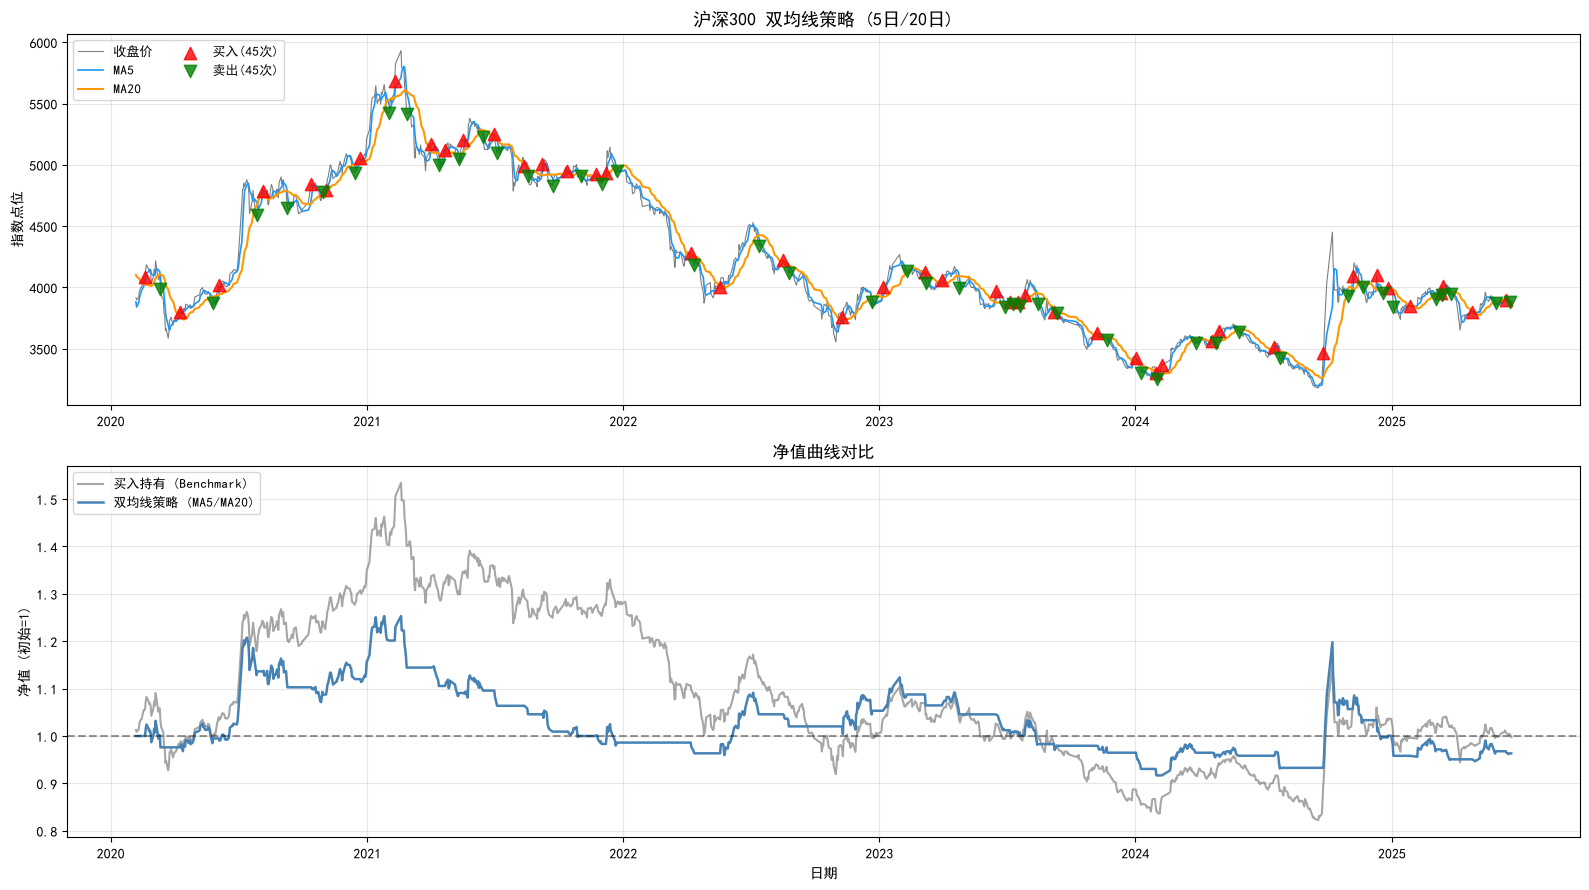

In [22]:
# 可视化对比
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# --- 上图：价格 + 均线 + 交易信号 ---
ax = axes[0]
ax.plot(df_ma['date'], df_ma['close'], color='black', linewidth=0.8, alpha=0.5, label='收盘价')
ax.plot(df_ma['date'], df_ma['ma_short'], color='#2196F3', linewidth=1.2, label=f'MA{SHORT_WINDOW}')
ax.plot(df_ma['date'], df_ma['ma_long'], color='#FF9800', linewidth=1.5, label=f'MA{LONG_WINDOW}')

# 标注买卖点
buy_signals = df_ma[df_ma['position_change'] == 1]
sell_signals = df_ma[df_ma['position_change'] == -1]
ax.scatter(buy_signals['date'], buy_signals['close'], 
           color='red', marker='^', s=80, zorder=5, label=f'买入({len(buy_signals)}次)', alpha=0.8)
ax.scatter(sell_signals['date'], sell_signals['close'], 
           color='green', marker='v', s=80, zorder=5, label=f'卖出({len(sell_signals)}次)', alpha=0.8)

ax.set_title(f'沪深300 双均线策略 ({SHORT_WINDOW}日/{LONG_WINDOW}日)', fontsize=13, fontweight='bold')
ax.set_ylabel('指数点位')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

# --- 下图：净值对比 ---
ax2 = axes[1]
ax2.plot(df_ma['date'], df_ma['benchmark_nav'], color='gray', linewidth=1.5, 
         alpha=0.7, label='买入持有 (Benchmark)')
ax2.plot(df_ma['date'], df_ma['strategy_nav'], color='steelblue', linewidth=1.8, 
         label=f'双均线策略 (MA{SHORT_WINDOW}/MA{LONG_WINDOW})')
ax2.set_title('净值曲线对比', fontsize=12)
ax2.set_xlabel('日期')
ax2.set_ylabel('净值 (初始=1)')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=1, color='black', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [23]:
# 策略绩效对比
def calc_strategy_stats(returns: pd.Series, name: str, rf: float = 0.025):
    """计算策略的关键绩效指标"""
    nav = (1 + returns).cumprod()
    annual_ret = returns.mean() * 252
    annual_vol = returns.std() * np.sqrt(252)
    sharpe = (annual_ret - rf) / annual_vol if annual_vol > 0 else 0
    
    running_max = nav.expanding().max()
    mdd = ((nav - running_max) / running_max).min()
    
    win_rate = (returns > 0).sum() / len(returns)
    avg_win = returns[returns > 0].mean() if len(returns[returns > 0]) > 0 else 0
    avg_loss = returns[returns < 0].mean() if len(returns[returns < 0]) > 0 else 0
    
    print(f"--- {name} ---")
    print(f"  年化收益率: {annual_ret*100:.2f}%")
    print(f"  年化波动率: {annual_vol*100:.2f}%")
    print(f"  夏普比率:   {sharpe:.3f}")
    print(f"  最大回撤:   {mdd*100:.2f}%")
    print(f"  胜率:       {win_rate*100:.1f}%")
    print(f"  平均盈利:   {avg_win*100:.3f}%")
    print(f"  平均亏损:   {avg_loss*100:.3f}%")
    print(f"  盈亏比:     {abs(avg_win/avg_loss):.2f}" if avg_loss != 0 else "  盈亏比: N/A")
    return {'annual_return': annual_ret, 'sharpe': sharpe, 'max_drawdown': mdd, 'win_rate': win_rate}

print("=" * 50)
bench_stats = calc_strategy_stats(df_ma['benchmark_return'], '买入持有(沪深300)')
print()
strategy_stats = calc_strategy_stats(df_ma['strategy_return'], f'双均线策略(MA{SHORT_WINDOW}/{MA{LONG_WINDOW})')

print()
print("=== 策略 vs 基准 ===")
print(f"超额收益: {(strategy_stats['annual_return'] - bench_stats['annual_return'])*100:.2f}%")
print(f"回撤改善: {(bench_stats['max_drawdown'] - strategy_stats['max_drawdown'])*100:.2f}%")

SyntaxError: f-string: unmatched ')' (2635393339.py, line 30)

## 8. 总结 & 下一步

通过这个 Notebook，你已经完成了量化投资的第一步：

| 能力 | 掌握情况 |
|------|----------|
| 用 Python 拉取真实金融数据 | ✅ |
| 计算收益率、波动率、夏普比率 | ✅ |
| 理解并计算最大回撤 | ✅ |
| 分析多资产相关性 | ✅ |
| 模拟一个完整的交易策略并评估 | ✅ |

### 关键洞察
1. **趋势跟踪策略在趋势市中表现好，震荡市中反复止损** — 这是双均线的天生缺陷
2. **没有免费的午餐** — 任何策略都有适应的市场环境和不适应的环境
3. **回测 ≠ 实盘** — 回测没有考虑滑点、冲击成本、流动性，实盘会更差

### 下一步
- 尝试修改 SHORT_WINDOW 和 LONG_WINDOW 参数，观察结果变化（这就是参数优化的雏形）
- 阅读《Quantitative Trading》前三章
- 思考：如果加上止损逻辑，结果会变好吗？
- 接下来我们将进入 **阶段1：搭建多市场数据管道**